In [1]:
import os
import shutil

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !pip -q install kaggle
# ! mkdir ~/.kaggle
# ! cp kaggle.json ~/.kaggle/
# !chmod 600 /root/.kaggle/kaggle.
# !kaggle datasets download -d marquis03/fruits-100
# shutil.copy2("/content/fruits-100.zip", "/content/drive/MyDrive/fruits-info")

chmod: cannot access '/root/.kaggle/kaggle.': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/marquis03/fruits-100
License(s): Apache 2.0
 99% 620M/627M [00:10<00:00, 12.8MB/s]
100% 627M/627M [00:10<00:00, 63.3MB/s]


'/content/drive/MyDrive/fruits-info/fruits-100.zip'

In [3]:
!unzip -q "/content/drive/MyDrive/fruits-info/fruits-100.zip" -d .

# **Imports**

In [4]:
!pip install -q tf2onnx
!pip install -q onnxruntime
!pip install -q onnx
!pip install -q onnxruntime-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 76.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 42.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.8/199.8 MB 2.5 MB/s eta 0:00:00


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import cv2
import random
import shutil
import time
import datetime
import onnx
import tf2onnx
import onnxruntime as ort
from PIL import Image
from pathlib import Path
from sklearn.metrics import confusion_matrix

# **Data**

In [ ]:
!ls

classname.txt  drive  sample_data  test  test.csv  train  train.csv  val  val.csv


In [6]:
train_dir = Path('/content/train/')
test_dir = Path('/content/test/')
val_dir = Path('/content/val/')
project_dir = Path('/content/drive/MyDrive/fruits-info/')

In [14]:
train_img = list(train_dir.glob('*/*.jpg'))
test_img = list(test_dir.glob('*/*.jpg'))
val_img = list(val_dir.glob('*/*.jpg'))

print(len(train_img), len(test_img), len(val_img))

40000 5000 5000


/content/train/cherimoya/217.jpg


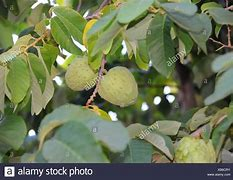

In [ ]:
print(train_img[0])
Image.open(str(train_img[0]))

/content/test/57/295.jpg


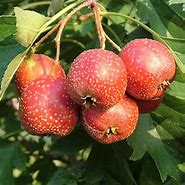

In [ ]:
print(test_img[0])
Image.open(str(test_img[0]))

/content/val/cherimoya/82.jpg


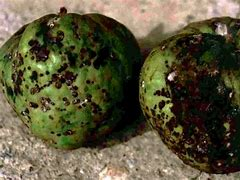

In [ ]:
print(val_img[0])
Image.open(str(val_img[0]))

In [ ]:
pd.read_csv('/content/train.csv').head()

,image:FILE,category
0,train/oil_palm/57.jpg,0
1,train/oil_palm/881.jpg,0
2,train/oil_palm/450.jpg,0
3,train/oil_palm/28.jpg,0
4,train/oil_palm/62.jpg,0


In [ ]:
pd.read_csv('/content/test.csv').head()

,image:FILE,category
0,test/28/596.jpg,-1
1,test/28/34.jpg,-1
2,test/28/686.jpg,-1
3,test/28/590.jpg,-1
4,test/28/521.jpg,-1


In [ ]:
pd.read_csv('/content/val.csv').head()

,image:FILE,category
0,val/oil_palm/102.jpg,0
1,val/oil_palm/637.jpg,0
2,val/oil_palm/186.jpg,0
3,val/oil_palm/559.jpg,0
4,val/oil_palm/129.jpg,0


In [15]:
with open('classname.txt', 'r') as f:
  classes = f.readlines()
  classnames = [x.strip() for x in classes]

In [ ]:
classnames[:10]

['oil_palm',
 'hog_plum',
 'apricot',
 'sugar_apple',
 'rambutan',
 'yellow_plum',
 'pineapple',
 'dewberry',
 'plumcot',
 'ambarella']

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',
    image_size=(128, 128),
    batch_size=32,
    shuffle=True,
    seed=13,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',
    image_size=(128, 128),
    batch_size=32
)

Found 40000 files belonging to 100 classes.
Found 5000 files belonging to 100 classes.


In [ ]:
print(train_ds.class_names[:5])
train_ds.class_names==sorted(classnames)

['abiu', 'acai', 'acerola', 'ackee', 'ambarella']


True

In [ ]:
train_ds, val_ds

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>)

(32, 128, 128, 3) (32, 100)


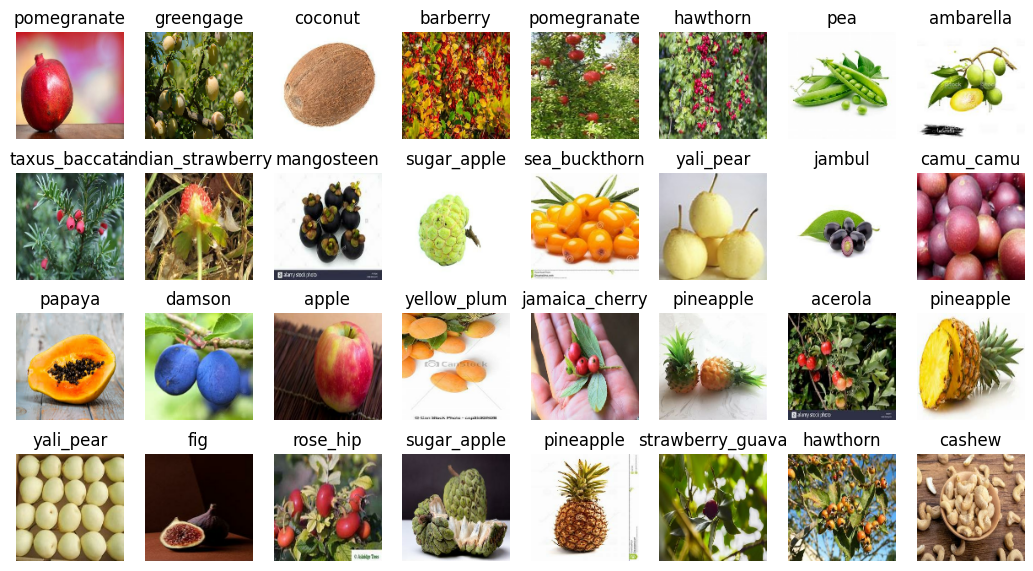

In [ ]:
%matplotlib inline

img, label = next(iter(train_ds))
print(img.shape, label.shape)

plt.figure(figsize=(13, 7))
for i in range(32):
  ax = plt.subplot(4, 8, i+1)
  plt.imshow(img[i].numpy().astype('uint8'))
  plt.title(train_ds.class_names[np.argmax(label[i])])
  plt.axis('off')

# **Augmentation**

In [ ]:
aug_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('vertical', seed=13),
    tf.keras.layers.RandomRotation(factor=(-0.05, 0.05)),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2, seed=13)
])

In [ ]:
def aug_func(img, label):
  img = aug_layer(img)
  return img, label

In [ ]:
aug_train_ds = (train_ds
                .map(aug_func, num_parallel_calls=tf.data.AUTOTUNE)
                .prefetch(tf.data.AUTOTUNE))
aug_train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>

(32, 128, 128, 3) (32, 100)


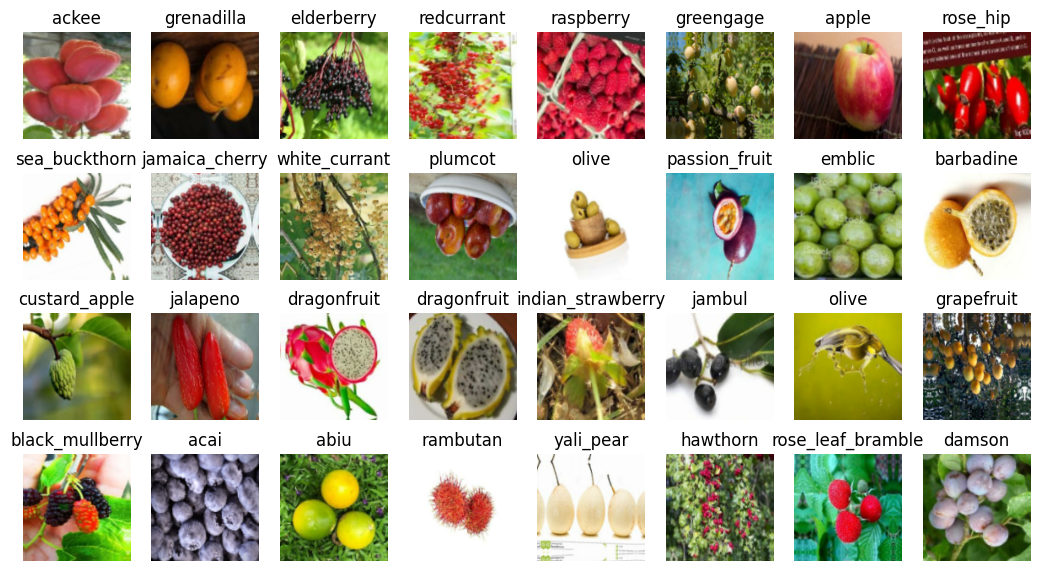

In [ ]:
%matplotlib inline

img, label = next(iter(aug_train_ds))
print(img.shape, label.shape)

plt.figure(figsize=(13, 7))
for i in range(32):
  ax = plt.subplot(4, 8, i+1)
  plt.imshow(img[i].numpy().astype('uint8'))
  plt.title(train_ds.class_names[np.argmax(label[i])])
  plt.axis('off')

# **Model**

In [ ]:
# effnetv2s = tf.keras.applications.EfficientNetV2S(
#     include_top=False,
#     weights='imagenet',
#     input_shape=(128, 128, 3)
#     )

In [ ]:
# effnetv2s.save(project_dir/'effnetv2s.h5')

In [ ]:
effnetv2s = tf.keras.models.load_model(project_dir/'effnetv2s.h5')
len(effnetv2s.layers), len(effnetv2s.trainable_variables)

(513, 450)

In [ ]:
# effnetv2s.summary()

In [ ]:
for layer in effnetv2s.layers[:450]:
  layer.trainable = False

len(effnetv2s.layers), len(effnetv2s.trainable_variables)

(513, 55)

In [ ]:
# effnetv2s.trainable = False

inputs = tf.keras.Input(shape=(128, 128, 3))
x = effnetv2s(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(500, activation='relu')(x)
x = tf.keras.layers.Dense(250, activation='relu')(x)
outputs = tf.keras.layers.Dense(100, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

In [ ]:
len(model.layers), len(model.trainable_variables)

(7, 61)

In [ ]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 efficientnetv2-s (Function  (None, 4, 4, 1280)        20331360  
 al)                                                             
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_3 (Dense)             (None, 500)               640500    
                                                                 
 dense_4 (Dense)             (None, 250)               1252

In [ ]:
metrics = [
    tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    # tf.keras.metrics.F1Score(name='f1_score'),
    tf.keras.metrics.Recall(name='recall'),
    # tf.keras.metrics.AUC(name='auc')
]

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=metrics)

In [ ]:
remove = f'{project_dir}/logs/tensorboard/'
shutil.rmtree(remove, ignore_errors=True)

In [ ]:
os.makedirs(project_dir/'logs/tensorboard/', exist_ok=True)
os.makedirs(project_dir/'saved_weights/', exist_ok=True)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    start_from_epoch=10,
    verbose=1
)

log_dir = f'{project_dir}/logs/tensorboard/'
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

filename = f"{project_dir}/training_logs"
log_csv = tf.keras.callbacks.CSVLogger(
    filename,
    separator=',',
    append=True
)

directory = f"{project_dir}/saved_weights/ckpt_model.keras"
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    directory,
    monitor='val_accuracy',
    save_best_only=True,
    mode='auto',
    save_freq='epoch',
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.9,
    patience=3,
    verbose=1,
    mode='auto',
    min_lr=0.0001,
)

In [ ]:
callbacks = [
    early_stopping,
    tensorboard_cb,
    checkpoint_cb,
    reduce_lr,
    log_csv
]

In [ ]:
history = model.fit(
    aug_train_ds,
    epochs=50,
    callbacks=callbacks,
    validation_data=val_ds
)

In [ ]:
df = pd.read_csv(project_dir/'training_logs')
df = df.iloc[2:]
# df.reset_index(drop=True, inplace=True)
df.set_index('epoch', inplace=True)
df.head()

,accuracy,loss,lr,precision,recall,val_accuracy,val_loss,val_precision,val_recall
epoch,,,,,,,,,
0,0.420675,2.179228,0.001,0.728782,0.260175,0.5668,1.502418,0.772387,0.4330
1,0.590100,1.426031,0.001,0.778613,0.455800,0.6316,1.259122,0.777549,0.5292
2,0.646725,1.198655,0.001,0.801943,0.534575,0.6660,1.171861,0.780730,0.5818
3,0.682500,1.063036,0.001,0.816938,0.583825,0.6794,1.101031,0.801626,0.5916
4,0.707125,0.957473,0.001,0.825459,0.617175,0.6888,1.096107,0.782511,0.6246


In [ ]:
loss = df['loss']
val_loss = df['val_loss']

acc = df['accuracy']
val_acc = df['val_accuracy']

precision = df['precision']
val_precision = df['val_precision']

recall = df['recall']
val_recall = df['val_recall']

In [ ]:
%matplotlib agg

plt.figure(figsize=(20, 16))
plt.subplot(2, 2, 1)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend(loc='upper right')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Val Loss')

plt.subplot(2, 2, 2)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend(loc='lower right')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train and Val Accuracy')

plt.subplot(2, 2, 3)
plt.plot(precision, label='Train Precision')
plt.plot(val_precision, label='Val Precision')
plt.legend(loc='lower right')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.title('Train and Val Precision')

plt.subplot(2, 2, 4)
plt.plot(recall, label='Train Recall')
plt.plot(val_recall, label='Val Recall')
plt.legend(loc='lower right')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Train and Val Recall')

plt.tight_layout()
fname = f'{project_dir}/plot-{datetime.datetime.now()}.png'
plt.savefig(fname, bbox_inches='tight', dpi=500)

Text(0.5, 1.0, 'Train and Val Recall')

In [ ]:
model.save(project_dir/'trained_model_2.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [7]:
model = tf.keras.models.load_model(project_dir/'trained_model_2.h5')

In [ ]:
model.evaluate(val_ds)

157/157 [==============================] - 15s 57ms/step - loss: 1.0481 - accuracy: 0.7224 - precision: 0.7954 - recall: 0.6786


[1.0481109619140625, 0.7224000096321106, 0.7953586578369141, 0.678600013256073]

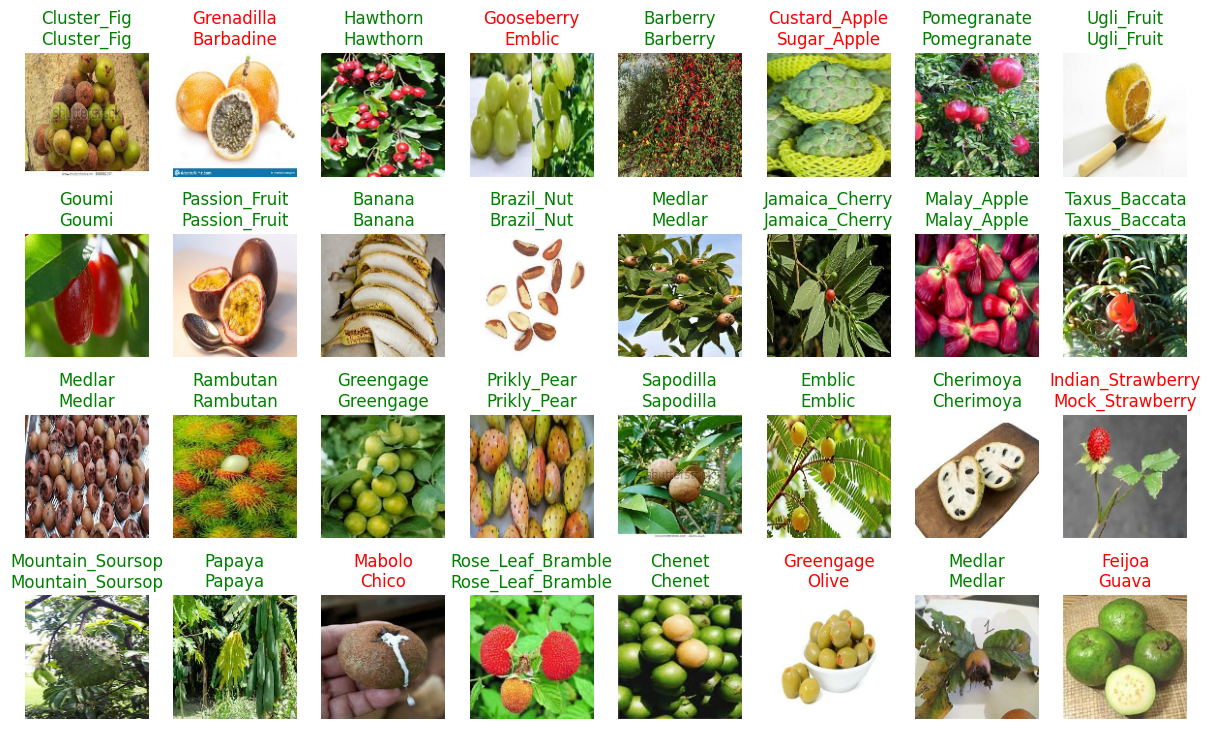

In [ ]:
%matplotlib inline

img, label = next(iter(val_ds))

plt.figure(figsize=(15, 9))
for i in range(32):
  plt.subplot(4, 8, i+1)
  plt.imshow(img[i].numpy().astype('uint8'))

  output = np.argmax(model(tf.expand_dims(img[i], axis=0)))
  pred = train_ds.class_names[output].title()
  actual = train_ds.class_names[np.argmax(label[i])].title()

  text = f'{pred}\n{actual}'

  if pred == actual:
    plt.title(text, color='green')
  else:
    plt.title(text, color='red')

  plt.axis('off')

In [ ]:
preds = []
labels = []

for image, label in val_ds.as_numpy_iterator():
  preds.append(model(image))
  labels.append(label)

In [ ]:
len(preds), len(labels), preds[0].shape, labels[0].shape

(157, 157, TensorShape([32, 100]), (32, 100))

In [ ]:
preds[0], labels[0]

(<tf.Tensor: shape=(32, 100), dtype=float32, numpy=
 array([[4.02989372e-07, 1.13417766e-04, 4.98944253e-01, ...,
         6.51004157e-05, 9.60992293e-06, 3.01299133e-05],
        [1.06306945e-12, 1.16378498e-08, 1.63847616e-11, ...,
         9.99978781e-01, 3.48618920e-12, 8.24273840e-08],
        [5.17315411e-14, 7.10342768e-14, 5.79601723e-16, ...,
         3.97598007e-16, 1.14388274e-18, 3.40264146e-15],
        ...,
        [1.74077353e-09, 6.35816422e-09, 9.40879318e-07, ...,
         8.76609440e-13, 1.82601460e-12, 4.42445458e-09],
        [3.31330230e-05, 3.68996278e-10, 1.14311930e-04, ...,
         1.15039445e-09, 8.13224210e-10, 3.50041264e-05],
        [9.28509841e-17, 9.21982296e-20, 2.58408436e-21, ...,
         7.86099159e-13, 1.69910336e-23, 7.83351724e-19]], dtype=float32)>,
 array([[0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0.

In [ ]:
len(preds[0][0]), len(labels[0][0])

(100, 100)

In [ ]:
(train_ds.class_names[np.argmax(preds[0][0])],
 train_ds.class_names[np.argmax(labels[0][0])])

('acerola', 'acerola')

In [ ]:
len(preds[:-1]), len(preds[-1]), len(labels[:-1]), len(labels[-1])

(156, 8, 156, 8)

In [ ]:
all_preds = np.concatenate(
    [np.argmax(preds[:-1], axis=-1).flatten(),
     np.argmax(preds[-1], axis=-1).flatten()]
)

all_labels = np.concatenate(
    [np.argmax(labels[:-1], axis=-1).flatten(),
     np.argmax(labels[-1], axis=-1).flatten()]
)

all_preds, all_labels

(array([ 2, 97, 15, ..., 61,  3, 11]), array([ 2, 97, 15, ..., 61,  3, 11]))

In [ ]:
print(all_preds==all_labels)
all_preds.shape, all_labels.shape

[ True  True  True ...  True  True  True]


((5000,), (5000,))

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm, cm.shape

(array([[46,  0,  0, ...,  0,  0,  0],
        [ 0, 42,  0, ...,  0,  0,  0],
        [ 0,  0, 32, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ..., 47,  0,  0],
        [ 0,  0,  0, ...,  0, 46,  1],
        [ 0,  0,  0, ...,  0,  1, 21]]),
 (100, 100))

In [ ]:
%matplotlib agg

ticks = np.arange(cm.shape[0])

plt.figure(figsize=(30, 25))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=ticks,
            yticklabels=ticks)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.tight_layout()
fname = f'{project_dir}/conf_matrix-{datetime.datetime.now()}.png'
plt.savefig(fname, bbox_inches='tight', dpi=500)

### Predict on Test Image

In [16]:
s_classnames = sorted(classnames)
print(s_classnames[:5])

['abiu', 'acai', 'acerola', 'ackee', 'ambarella']


In [ ]:
random_image = str(random.choice(val_img))
random_image_class = random_image.split('/')[3]

In [ ]:
print(random_image)
print(random_image_class)

/content/val/pomegranate/420.jpg
pomegranate


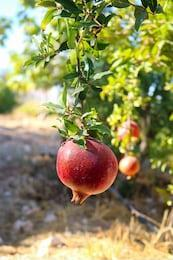

In [ ]:
Image.open(random_image)

In [ ]:
img = cv2.imread(random_image)
img = cv2.resize(img, (128, 128))
img_tensor = tf.constant(img, dtype=tf.float32)
img_tensor = tf.expand_dims(img_tensor, axis=0)
pred_value = model.predict(img_tensor)

1/1 [==============================] - 0s 33ms/step


In [ ]:
# print(pred_value)

In [ ]:
print(train_ds.class_names[np.argmax(pred_value)])
print(s_classnames[np.argmax(pred_value)])

pomegranate
pomegranate


In [ ]:
sample_img_ls = []

for i in range(10):
  random_img = str(random.choice(val_img))
  sample_img_ls.append(random_img)

sample_img_ls

['/content/val/acai/28.jpg',
 '/content/val/raspberry/688.jpg',
 '/content/val/cherimoya/358.jpg',
 '/content/val/sea_buckthorn/473.jpg',
 '/content/val/cranberry/3.jpg',
 '/content/val/dewberry/675.jpg',
 '/content/val/kumquat/64.jpg',
 '/content/val/hard_kiwi/186.jpg',
 '/content/val/bitter_gourd/204.jpg',
 '/content/val/santol/965.jpg']

In [ ]:
shutil.rmtree(project_dir/'sample_images')

In [ ]:
os.makedirs(project_dir/'sample_images')

In [ ]:
for item in sample_img_ls:
  name = item.split('/')[3]
  shutil.copy2(src=item, dst=f'{project_dir}/sample_images/{name}.jpg')

In [9]:
sample_img_dir = Path(project_dir/'sample_images')
sample_img_dir

PosixPath('/content/drive/MyDrive/fruits-info/sample_images')

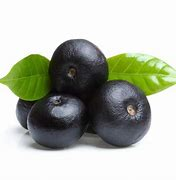

In [23]:
img = str(sample_img_dir/'acai.jpg')
Image.open(img)

In [13]:
img = cv2.imread(img)
img = cv2.resize(img, (128, 128))
img_tensor = tf.constant(img, dtype=tf.float32)
img_tensor = tf.expand_dims(img_tensor, axis=0)
pred_value = model.predict(img_tensor)

1/1 [==============================] - 6s 6s/step


In [17]:
s_classnames[np.argmax(pred_value)]

'acai'

### Convert to ONNX

In [18]:
os.makedirs(project_dir/'onnx', exist_ok=True)

In [19]:
input_signature = [
    tf.TensorSpec(
        [None, 128, 128, 3],
        tf.float32,
        name='input'
    )
]

output_path = project_dir/'onnx/finetuned_effv2s_128x128.onnx'

In [20]:
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature, opset=13)
onnx.save(onnx_model, output_path)

output_names = [n.name for n in onnx_model.graph.output]
print(f'\n{output_names}')


['dense_5']


In [27]:
img = str(sample_img_dir/'acai.jpg')
img = cv2.imread(img)
img = np.float32(cv2.resize(img, (128, 128)))
img_tensor = np.expand_dims(img, axis=0)
img_tensor.shape

(1, 128, 128, 3)

In [28]:
onm = ort.InferenceSession(output_path, providers=['CUDAExecutionProvider'])
onnx_preds = onm.run(['dense_5'], {'input': img_tensor})
s_classnames[np.argmax(onnx_preds)]

'acai'

In [31]:
items_to_zip = [
    project_dir/'onnx',
    project_dir/'sample_images',
    project_dir/'fruits-info.ipynb',
    project_dir/'training_logs',
    project_dir/'plot-2024-06-17 12:48:51.768350.png',
    project_dir/'conf_matrix-2024-06-17 13:55:57.014995.png',
    ]

In [ ]:
import pathlib
import zipfile

items_to_zip = [pathlib.Path(item) for item in items_to_zip]

with zipfile.ZipFile(project_dir/'fruits-info.zip', 'w') as zip_file:
    for item in items_to_zip:
        if item.is_file():
            zip_file.write(item)
        elif item.is_dir():
            for file in item.rglob('*'):
                zip_file.write(file)


### Quantizing